## Exam (60 pts)

***
**Note:**

(1) <span style="color:red">This is an **individual effort-based exam. Please uphold the GMU Academic Standards and work on your own to complete the exam.**</span>

(2) 🔴**Due Date: December 21st, 2025, Sunday 11:59:59 PM EST**.🔴 For each minute the submission is late, a 1% penalty is applied.

(3) <span style="color:red">Do not create any new cells on this Jupyter Notebook file. All codes should be completed in the existing cells provided.</span>

(4) <span style="color:red">Make sure to run your code for each cell so that the output/result is visible underneath each code cell. **I will run your code from top to bottom, and you should do so as well after all codes are ready. Make sure your output matches with what would be produced by your code. For each question, if your output as shown in the submitted file does not match with your code, you will automatically lose most of the points.**</span>

(5) I understand that each coding task can be completed in many different ways (e.g., using different functions or methods). Acknowledging this, it is also 100% certain that each coding task can be completed only using the skills covered in the class and introduced in the homework assignments. <span style="color:red">**To demonstrate that you've grasped these skills, you are required to apply Python skills covered in the course to complete each task.** Once you have done so, you are welcome to demonstrate alternative solution(s) to each coding task using skills not covered in class.</span>

(6) <span style="color:red">You need to submit your completed Jupyter Notebook file (.ipynb) AND a PDF version of it to Canvas. **Both files must be uploaded to Canvas in ONE submission (these are not to be submitted separately under two submissions)**. Please make sure that the PDF file shows the output of each code cell. Submissions without the valid PDF file as instructed or submissions without the valid Jupyter Notebook file as 
instructed will result in an automatic grade penalty of 25%. **Again, I will run your code from top to bottom, it is your responsibility to make sure the code file (.ipynb) you submit is the correct code file you intend to submit.**</span> 
***

### Part 0: Get Ready

<span style="color:red">**(1 pts)**</span> **T0-1:** To help differentiate your submission file from others, first, rename this Jupyter Notebook file (.ipynb file) in this format: "LastName_G#_exam.ipynb”. For example, the Jupyter Notebook file you submit should be like "Ye_12345678_exam.ipynb" where "Ye" is the last name and 12345678 is the G# without "G" in this example. Same applies to the PDF version of the file. You will complete the exam questions below on this Jupyter Notebook file, and then submit the completed the Jupyter Notebook file as well as its PDF version.

### Business Context and Data

An online retailer wants to know what customers are not happy and may potentially churn, so that they can take preventive measures (e.g., reach out to them, offer better promos to them). The retailer has sent a short satisfaction survey to their users and received some responses. **You will apply the Python data analytics skills learned from this class to help the retailer.**

Information of customers who have responded to the survey are extracted from different tables in the retailer's database and saved as different *csv* files, as explained below. Note that as many more features related to each customer are not included here, the R-squared of a linear regression model is not expected to be high.

**1. Customer information** split into two data files: *"customer1.csv"* and *"customer2.csv"*

| Variable           | Explanation                                                                                              |
| :------------------| :--------------------------------------------------------------------------------------------------------|
| CustomerID         | This is an artifically created ID just to uniquely identify each customer.                               |
| NumDevice          | The number of devices the customer has used to visit the retailer's site or app.                         |
| NumAddr            | The number of addresses saved in the customer's account.                                                 |
| NumCards           | The number of saved cards for payment in the cutomer's account                                           |

**2. Customer activity information** in *"activity.csv"*

| Variable           | Explanation                                                                                              |
| :------------------| :--------------------------------------------------------------------------------------------------------|
| CustomerID         | This is an artifically created ID just to uniquely identify each customer.                               |
| VisitHours         | The number of hours the customer spent on the retailer's wesbite or mobile app in recent 2 months.       |
| NumTicket          | The number of support ticket the customer has submitted in recent 2 months.                              |
| NumCouponUsed      | The number of coupons the customer has redeemed in recent 2 months.                                      |
| NumOrder           | The number of orders the customer has placed in recent 2 months.                                         |
| Spending           | The total spending (in US Dollar) from the customer in recent 2 months.                                  |

**3. Survey result** in *"survey.csv."* 
| Variable           | Explanation                                                                                              |
| :------------------| :--------------------------------------------------------------------------------------------------------|
| CustomerID         | This is an artifically created ID just to uniquely identify each customer.                               |
| Satisfaction       | Customer satisfactions score (from 1 very unsatisfied to 7 very satisfied) from a recent survey.         |

**<span style="color:red">Note: There is another csv file *"customer_to_predict.csv"* containing data for customers whose satisfaction score is unknown  and needs to be predicted. This file is only needed for the T1-8.</span>**

### Part 1: Preparing Data

<span style="color:red">**(6 pts)**</span> **T1-1:** Prepare the data and get it ready for analysis. You need to do appropriate data concatenation, data merging, data cleaning, and data transformation (if needed) to produce a finalized DataFrame for subsequent analyses that: (1) contains all customer-related information and columns from the data files; (2) has no duplicate row index labels; and (3) does not have data quality issues. There are three known data quality issues: (1) some data are missing; (2) some customers' satisfaction scores are wrongly recorded as 0 due to a backend coding bug; (3) data inconsistency: the total spending of some customers who purchased in the past 2 months is correctly recorded but their number of order is wrongly recorded as 0. Once the finalized DataFrame is ready, **print its shape, a succint summary of the DataFrame (such as columns, non-null values, data types of columns, etc.), and the first 5 rows.**

In [36]:
# T1-1 python solution code below
import pandas as pd
customer_1 = pd.read_csv("customer1.csv")
customer_2 = pd.read_csv("customer2.csv")
activity = pd.read_csv("activity.csv")
survey = pd.read_csv("survey.csv")
customer_all = pd.concat([customer_1, customer_2], ignore_index=True)
customer_final1 = pd.merge(customer_all, activity, on="CustomerID")
customer_cleaned_version = pd.merge(customer_final1, survey, on = "CustomerID")
customer_cleaned_version.dropna(inplace=True)
condition1 = customer_cleaned_version["Satisfaction"] == 0
condition2 = customer_cleaned_version["NumOrder"] == 0  
condition3 = customer_cleaned_version["Spending"] > 0
condition_to_remove = customer_cleaned_version[condition1 | condition2 & condition3]
customer_cleaned_version.drop(condition_to_remove.index, inplace=True)
print(customer_cleaned_version.shape)
print()
print(customer_cleaned_version.head(5))
print()
print(customer_cleaned_version.info())

(5307, 10)

   CustomerID  NumDevice  NumAddr  ...  NumOrder  Spending  Satisfaction
0        1001        2.0        2  ...       1.0    139.92             2
1        1002        3.0        2  ...       1.0    100.92             4
2        1003        3.0        1  ...       1.0    100.28             4
3        1004        5.0        1  ...       1.0    174.08             6
4        1005        4.0        1  ...       1.0    169.60             6

[5 rows x 10 columns]

<class 'pandas.core.frame.DataFrame'>
Index: 5307 entries, 0 to 5315
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     5307 non-null   int64  
 1   NumDevice      5307 non-null   float64
 2   NumAddr        5307 non-null   int64  
 3   NumCards       5307 non-null   float64
 4   VisitHours     5307 non-null   float64
 5   NumTicket      5307 non-null   int64  
 6   NumCouponUsed  5307 non-null   float64
 7   NumOrder       5307 non

<span style="color:red">**(4 pts)**</span> **T1-2:** You need to split the data into training and test data, as you are going to use the training sample to build and tune a model for predicting customer satisfaction, and test the performance of the model on the test data. **Make sure the training-testing split is replicable, once done, and print the shape of relevant DataFrame or Series variables.**

In [37]:
# T1-2 python solution code below
from sklearn.model_selection import train_test_split

independent_var = customer_cleaned_version.columns.to_list()
independent_var.remove("Satisfaction")
independent_var.remove("CustomerID")

X = customer_cleaned_version[independent_var]
Y = customer_cleaned_version["Satisfaction"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test:", Y_test.shape)

X_train: (4245, 8)
X_test: (1062, 8)
Y_train: (4245,)
Y_test: (1062,)


### Part 2: Linear Regression

<span style="color:red">**(7 pts)**</span> **T1-3:** Before you build your linear regression model using the training data, you can explore your training data a bit. You are interested in exploring the potential relationship between a customer's spending and their satisfaction score. Specifically, you are interested in answering this business question: are customers who spend more have a higher satisfaction level with the retailer? **To expore this question, you can use data visualization to compare the average spending of customers with different satisfaction levels, you are required to present this visualization in two different ways: (1) based on relevant summary data that you generate first; and (2) directly using the raw data without generating any summary data. Make sure the charts have a meaningful title and meaningful descriptions of both axes. Then print your answer to the business question based on your visual examination of the graph.**

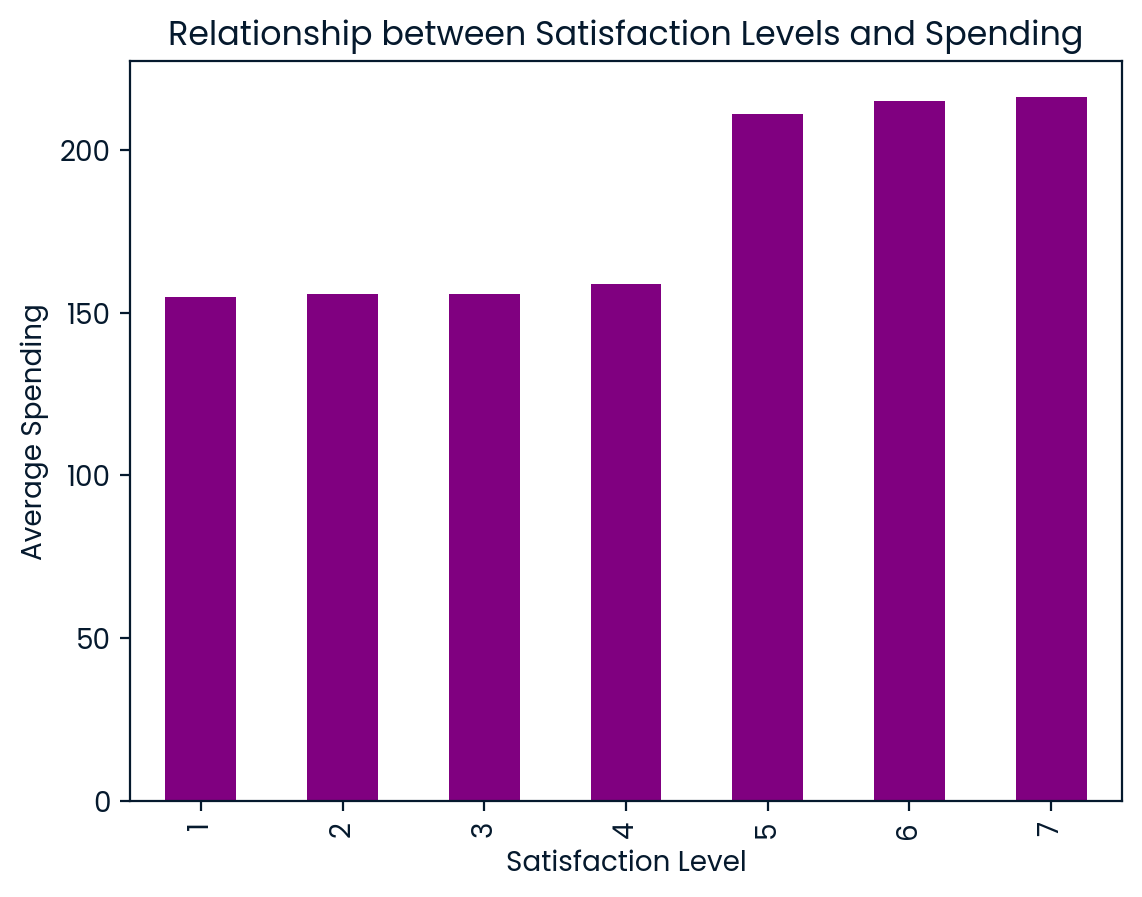

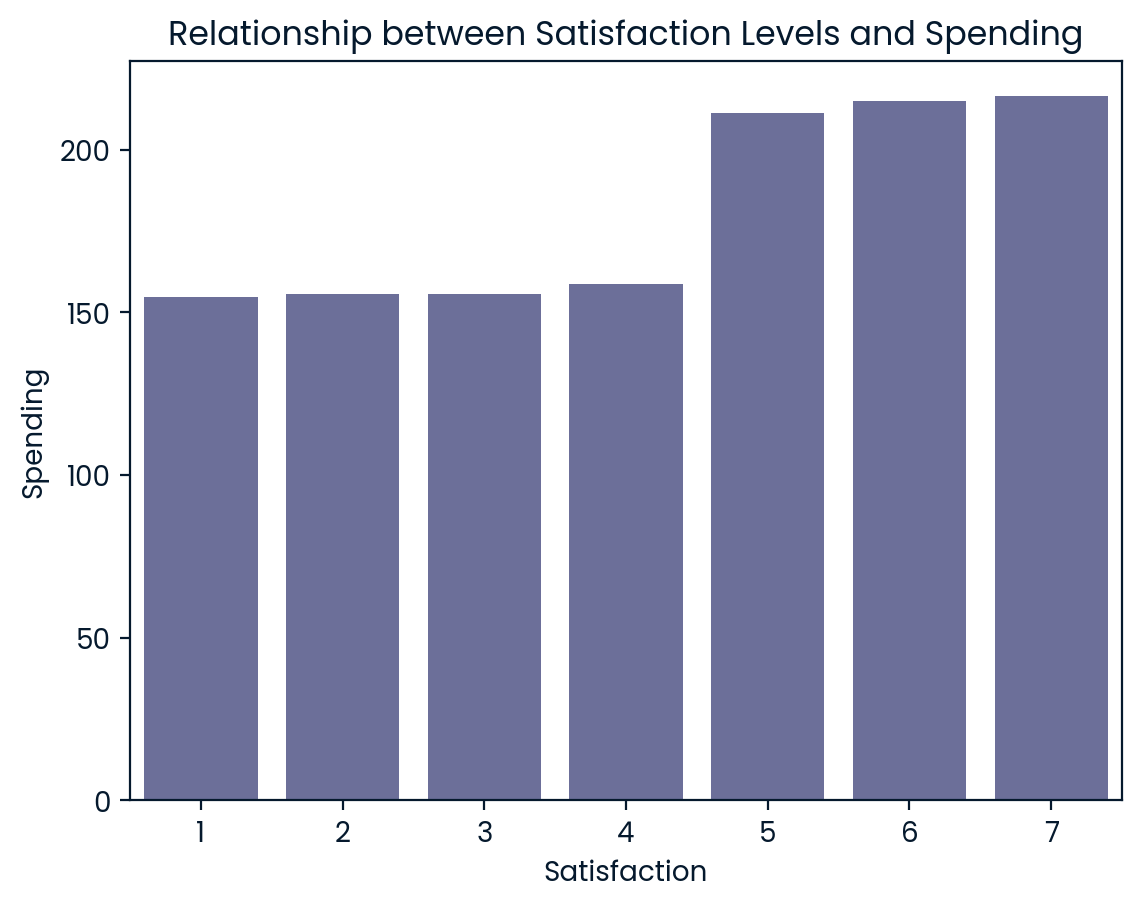


It shows that customers who spend more tend to have higher satisfaction levels with the retailer, based on the graph.


In [38]:
# T1-3 python solution code below
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.concat([X_train, Y_train], axis = 1)
test = pd.concat([X_test, Y_test], axis = 1)

#1: First way:    
customer_by_satisfaction = train.groupby("Satisfaction")
avg_spending_by_satisfaction = customer_by_satisfaction["Spending"].mean().round(2)
avg_spending_by_satisfaction.plot.bar(title = "Relationship between Satisfaction Levels and Spending",    
                                     color = "purple",    
                                     xlabel = "Satisfaction Level",    
                                     ylabel = "Average Spending")
plt.show()

#2: Second way:
sns.barplot(data=train, x = "Satisfaction", y = "Spending", errorbar=None)
plt.title("Relationship between Satisfaction Levels and Spending")
plt.show()

print()
print("It shows that customers who spend more tend to have higher satisfaction levels with the retailer, based on the graph.")


<span style="color:red">**(6 pts)**</span> **T1-4:** In practice, your intuition and domain knowledge often help you decide what features might be good predictors and can be included in the model. (1) Based on your exploration in T1-3 and your intuition, pick **4 features** that your think might be good predictors of a customer's satisfaction score with the online retailer; (2) use the *statsmodels.api* package to run a multiple linear regression model with the training data on the 4 predictors; (3) **print the summary of the regression results**; (4) **write a loop** to examine the regression results and **print features line by line that are significant and positive predictors of a customer's satisfaction score** (i.e., each line is the name of a feature/ predictor that has a significant and positive relationship with customer satisfaction). Again, do not use any skills (functions, methods, etc.) that are not covered in class.

In [39]:
# T1-4 python solution code below
selected_features = ["VisitHours", "NumCouponUsed", "NumOrder", "Spending"]
import statsmodels.api as sm
X2_train = X_train[selected_features]
X2_train = sm.add_constant(X2_train)
regression1 = sm.OLS(Y_train, X2_train).fit()
print(regression1.summary())
print()
pvalues = regression1.pvalues.round(3)
pvaluef = pvalues.tail(-1)
coefs = regression1.params.tail(-1).round(3)

for feature in regression1.params.index:
    coef = regression1.params[feature]
    pvalue = regression1.pvalues[feature]
    if feature != "const" and coef > 0 and pvalue <= 0.05:
        print(f"{feature} is a significant predictor and has positive relationship with customer satisfaction's score.")


                            OLS Regression Results                            
Dep. Variable:           Satisfaction   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     219.0
Date:                Sun, 21 Dec 2025   Prob (F-statistic):          4.30e-171
Time:                        06:44:10   Log-Likelihood:                -8040.4
No. Observations:                4245   AIC:                         1.609e+04
Df Residuals:                    4240   BIC:                         1.612e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.2649      0.123     10.256

<span style="color:red">**(7 pts)**</span> **T1-5:** Domain knowledge and hunch tells you that those 4 features in T1-4 may not make the best model. To help determine the best features that should be included in the linear regression model for predicting a customer's satisfaction score, you are going to use L1 Regularization (i.e., Lasso Regression) to run the linear regression model and select the features at the same time. You will **write a loop to perform Lasso Regression models with five different alphas (i.e., penalty factors or regularization strengths): 0.001, 0.01, 0.1, 0.3, and 0.5, and print out the coefficients of features in each Lasso Regression to see what features will be included in each regression.** Note: if you are not able to complete it using a loop, you can do the Lasso Regressions one by one in your code to get partial credit.

In [40]:
# T1-5 python solution code below
#Standardize the feature values:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#L1 Regularization:
alphas = [0.001, 0.01, 0.1, 0.3, 0.5]
for alpha in alphas:
    lasso_model = Lasso(alpha = alpha)
    lasso_model.fit(X_train_scaled, Y_train)
    lasso_coefs = pd.Series(data= lasso_model.coef_, index = independent_var)
    print(f"With alpha = {alpha}, we have the following results:")
    print(lasso_coefs)
    print()

With alpha = 0.001, we have the following results:
NumDevice        0.802782
NumAddr          0.019873
NumCards        -0.003563
VisitHours       0.197807
NumTicket       -0.107374
NumCouponUsed    0.124257
NumOrder        -0.023605
Spending         0.363104
dtype: float64

With alpha = 0.01, we have the following results:
NumDevice        0.795735
NumAddr          0.010694
NumCards        -0.000000
VisitHours       0.185508
NumTicket       -0.098875
NumCouponUsed    0.115335
NumOrder        -0.014444
Spending         0.355138
dtype: float64

With alpha = 0.1, we have the following results:
NumDevice        0.730467
NumAddr          0.000000
NumCards         0.000000
VisitHours       0.052537
NumTicket       -0.012829
NumCouponUsed    0.034149
NumOrder        -0.000000
Spending         0.285255
dtype: float64

With alpha = 0.3, we have the following results:
NumDevice        0.586777
NumAddr          0.000000
NumCards         0.000000
VisitHours       0.000000
NumTicket       -0.000000

<span style="color:red">**(12 pts)**</span> **T1-6:** To fine-tune the regression model, you are going to use Lasso Regression with cross-validation to find the optimal alpha value (i.e., penalty factor or regularization strength) for the best Lasso Regression model. You need to: **(1) find and print the optimal alpha value for the best Lasso Regression model; (2) evaluate the best model by calculating and printing the R-squared of the model on the traing data and the predicted R-squared on the test data; (3) present an appropriate visualization to demonstrate the importance of each feature in the best model, with features ranked by their importance in the chart**.

Optimal alpha value: 0.0071287212676323245
The R-squared of the model on the training data is: 0.337
The Predicted R-squared of the model on the test data is: 0.353


/home/repl/.venv-user/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning:

'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.



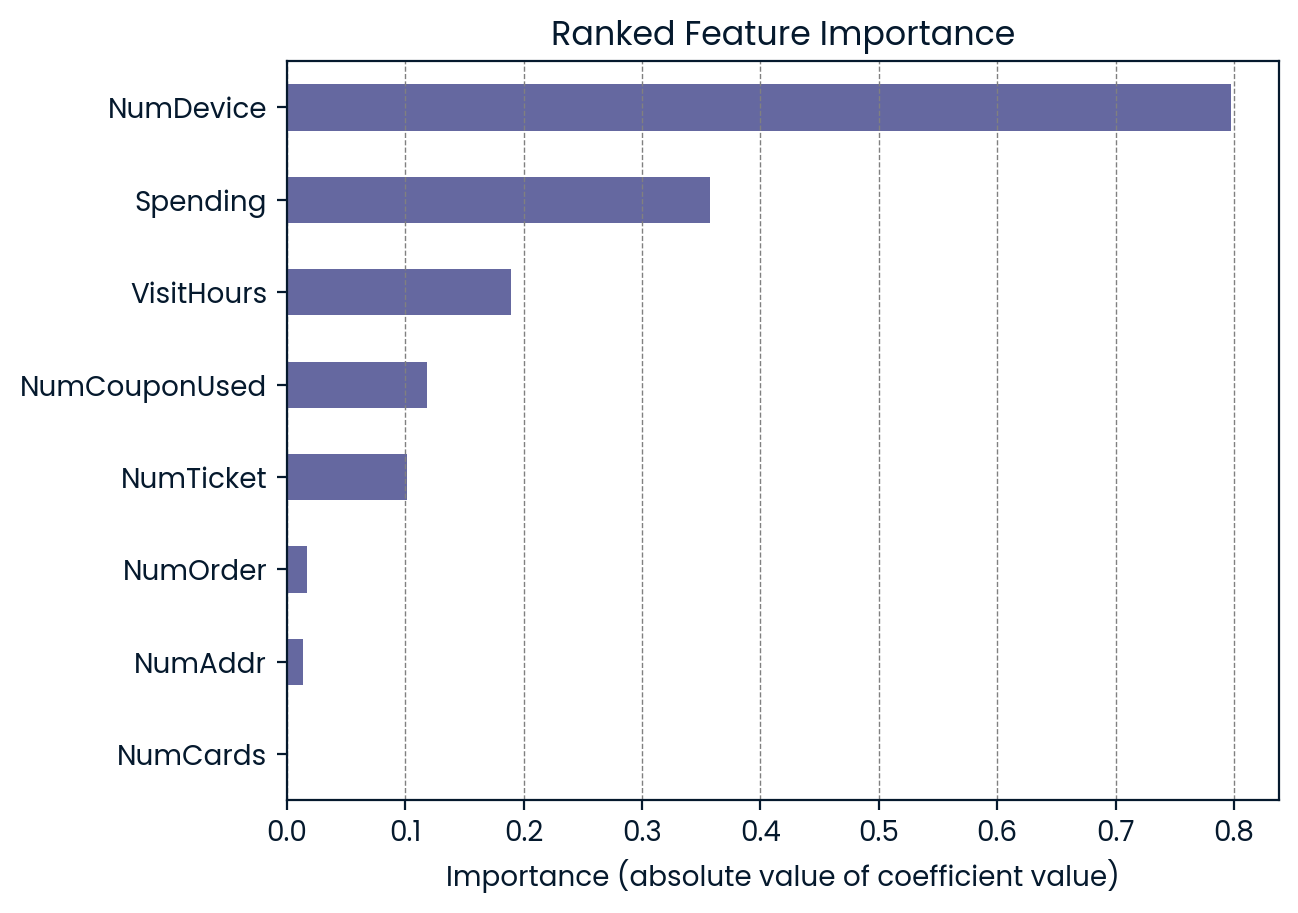

In [41]:
# T1-6 python solution code below
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

#1: Find and print the optimal alpha value for the best Lasso Regression Model:
kf = KFold(n_splits=5, shuffle=True, random_state=123)
alphas = np.arange(0.001, 1.2, 0.001)
lassocv_model = LassoCV(cv = kf, alphas=None)
lassocv_model.fit(X_train_scaled, Y_train)
print(f"Optimal alpha value: {lassocv_model.alpha_}")

#2: Calulate R-squared & predicted R-squared:
r2_train = lassocv_model.score(X_train_scaled, Y_train)
print(f"The R-squared of the model on the training data is: {r2_train:.3f}")

r2_test = lassocv_model.score(X_test_scaled, Y_test)
print(f"The Predicted R-squared of the model on the test data is: {r2_test:.3f}")

#3: Visualization:
lasso_coefs = pd.Series(data= lassocv_model.coef_, index = independent_var)
feature_importance = lasso_coefs.abs()
feature_importance.sort_values(inplace = True)
feature_importance.plot.barh()
plt.title("Ranked Feature Importance")
plt.xlabel("Importance (absolute value of coefficient value)")
plt.grid(visible=True, axis="x", linestyle = "--", color= "gray", linewidth = 0.5)
plt.show()

### Part 3: Classification - Logistic Regression

<span style="color:red">**(10 pts)**</span> **T1-7:** To further help the retailer, you are going to build a model to predict and identify potentially churning customers so that the retailer can take measures to prevent them from churning. You will use logistic regression to help classify customers into two groups: Unsatified Customer (that might be churning, which is the retailer's focus, i.e., positives), and Satisfied Customer (i.e., negatives). An Unsatified customer is defined as a customers whose satisfaction level is below 6, and a satisfied customer is defined as a customer whose satisfaction level is 6 or 7. You will need to: **(1) create a copy of the DataFrame for linear regression as the data for this classification model; (2) construct a new dependent variable for a logistic regression model with the same features/predictors used by the best Lasso Regression model in T1-6 (you need to identify and obtain them through Python coding); (3) do a 80-20 replicable split to split the data into training data and test data; (4) run the logistic regression model on the training data (make sure it is a traditional model that does not use any regularization); (5) demonstrate the performance of the model on the test data by printing the overall accuracy of the model on the test data, presenting the heatmap of the confusion matrix of the prediction model on the test data, and printing a classification report of the model on the test data.**

Overall prediction accuracy on test data: 0.7947



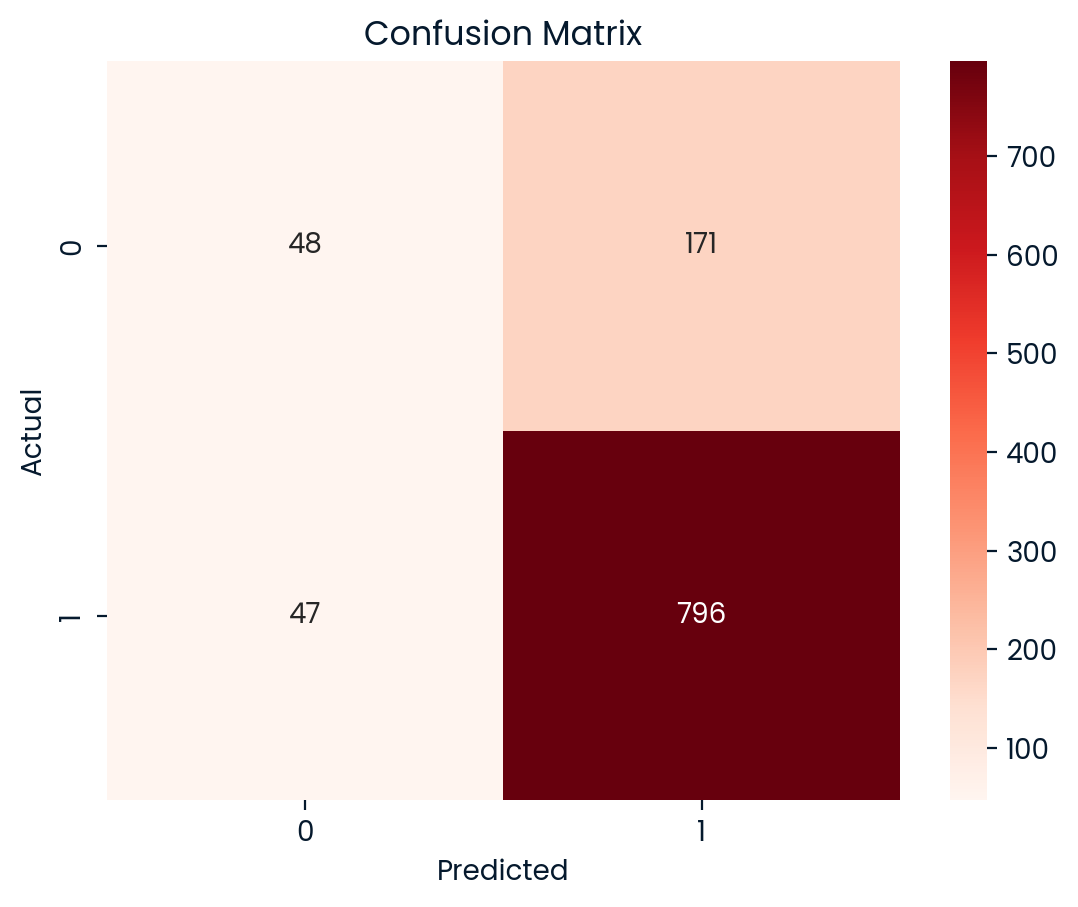


              precision    recall  f1-score   support

           0       0.51      0.22      0.31       219
           1       0.82      0.94      0.88       843

    accuracy                           0.79      1062
   macro avg       0.66      0.58      0.59      1062
weighted avg       0.76      0.79      0.76      1062



In [42]:
# T1-7 python solution code below
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("always")
#1: Create a copy of the Dataframe for linear regression as the data for this classification model
customer_cleaned_version_copy = customer_cleaned_version.copy()
#2: Construct a new dependent variable
customer_cleaned_version_copy["Unsatisfied"] = (customer_cleaned_version_copy["Satisfaction"] < 6).mul(1)
selected_features = lasso_coefs[lasso_coefs != 0].index.tolist()
#3: Do a 80-20 replicable split:
X3 = customer_cleaned_version_copy[selected_features]
Y3 = customer_cleaned_version_copy["Unsatisfied"]

X3_train, X3_test, Y3_train, Y3_test = train_test_split(X3, Y3, test_size=0.20, random_state=42)

#4: Run the logistic regression model:
c_model = LogisticRegression(penalty=None, max_iter=2000)
c_model.fit(X3_train, Y3_train)
#5: Demonstrate the performance:
#5.1: Print the Overall Pred Accuracy:
accuracy_train = c_model.score(X3_train, Y3_train)
Y3_pred = c_model.predict(X3_test)
accuracy_test = accuracy_score(Y3_test, Y3_pred)
print(f'Overall prediction accuracy on test data: {accuracy_test:.4f}')
print()
#5.2: Presenting heatmap:
cm = confusion_matrix(Y3_test, Y3_pred)
sns.heatmap(cm, annot= True, fmt= "d", cmap = "Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print()
#5.3: Printing Classification report:
report = classification_report(Y3_test, Y3_pred)
print(report)

<span style="color:red">**(7 pts)**</span> **T1-8:** The ultimate business question: who are the unsatisfied ones among customers whose satisfaction score is unknown? Again, the data of customers whose satisfaction scores are unknown and need to be predicted is in '*customer_to_predict.csv*'. **Find customers who are predicted to be unsatisfied and print their CustomerIDs only (i.e., do not print any other columns or results)**.

In [43]:
# T1-8 python solution code below
customer_satisfaction_to_pred = pd.read_csv("customer_to_predict.csv")
X_pred = customer_satisfaction_to_pred[selected_features]
customer_satisfaction_to_pred["Unsatisfied"] = c_model.predict(X_pred)
print(customer_satisfaction_to_pred.loc[customer_satisfaction_to_pred["Unsatisfied"]==1, ["CustomerID"]])

   CustomerID
0        6531
1        6532
3        6534
4        6535
5        6536
6        6537
8        6539
9        6540


## End of Exam
<span style="color:red">Once you have completed it and run all the cells from top to bottom sequentially, please remember to **submit both the Jupyter Notebook file and its PDF version that are named as instructed** to Canvas, as both are required.</span>